# SO 844: Gap at 10 au

In [1]:
from DBNets import DBNets2
import matplotlib.pyplot as plt

dbnets = DBNets2()

In [2]:
file_name = '/Users/kaileyliou/Documents/sigma-orionis-dbnets/images/SO844_continuum_final.image.pbcor.fits'
centre = (1000, 1000)
inclination = 30.7
pa = 109-90
distance = 408.4
rp = 10
res_ba_arcsec = 0.019

In [3]:
res_sigma = res_ba_arcsec/2.355*distance/rp

(np.float64(-0.5), np.float64(1999.5), np.float64(1999.5), np.float64(-0.5))

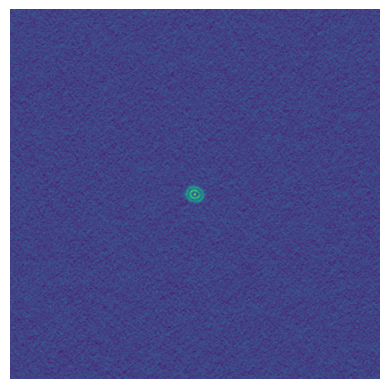

In [4]:
from astropy.io import fits

hdu = fits.open(file_name)[0]
plt.imshow(hdu.data[0,0])
plt.axis('off')

In [5]:
from DBNets import preproc as pp
deproj_image = pp.deproject_image(file_name, distance, inclination, pa, centre, rp)

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

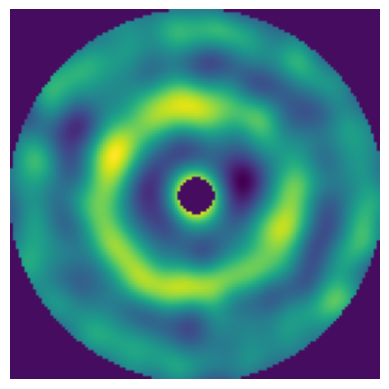

In [6]:
import matplotlib.pyplot as plt
plt.imshow(deproj_image)
plt.axis('off')

In [7]:
samples, cs = dbnets(deproj_image, [res_sigma], nsamples=50000)

10100it [00:00, 17521.40it/s]                                                  
100%|███████████████████████████████████| 9951/9951 [00:00<00:00, 19456.29it/s]
10118it [00:00, 19488.65it/s]                                                  
100%|███████████████████████████████████| 9993/9993 [00:00<00:00, 19325.39it/s]

loading all data and parameters
Sample 10 estimates from the posteriror distribution
Interpolating 10 best estimates
Standardize data
FFT
done.
 Compute metric..
DONE!


In [8]:
import numpy as np
np.median(np.nan_to_num(samples), axis=1)

array([[0.00016508, 0.06675541, 0.00161481, 0.00174029]])

In [9]:
from DBNets import utils

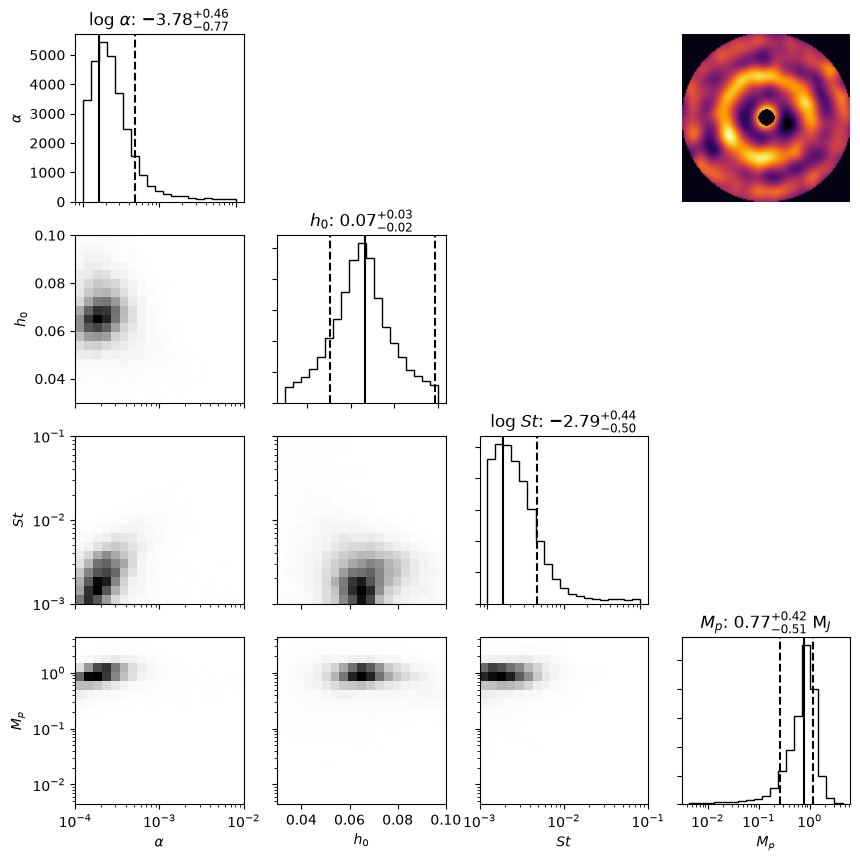

In [10]:
utils.plot_corner(samples[0],name='/Users/kaileyliou/Documents/sigma-orionis-dbnets/images/SO844_continuum_final.image.pbcor.fits', 
                  savepath='/Users/kaileyliou/Documents/sigma-orionis-dbnets/outputs/so844_gap10.pdf', image = deproj_image, starmass=440)

In [11]:
print(f'Confidence score: {cs[0]:.2f}')

Confidence score: 0.71
